IBTrACS data processing


In [10]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
ibtracs_raw = pd.read_csv(
    '../data/IBTrACS.WP.list.v04r01.csv',
    skiprows=[1],
    na_values=[' ', '']
)

C:\Users\SAM\AppData\Local\Temp\ipykernel_9916\2661992464.py:4: DtypeWarning: Columns (0: WMO_AGENCY, 1: USA_AGENCY, 2: USA_ATCF_ID, 3: USA_STATUS, 4: HKO_CAT, 5: KMA_CAT, 6: NEWDELHI_GRADE, 7: DS824_STAGE) have mixed types. Specify dtype option on import or set low_memory=False.
  ibtracs_raw = pd.read_csv(


In [8]:
cols_needed = [
    'SID', 'SEASON', 'NAME', 'ISO_TIME',
    'LAT', 'LON',
    'WMO_WIND', 'USA_WIND',
    'TRACK_TYPE'
]
ibtracs = ibtracs_raw[cols_needed].copy()

ibtracs.columns = [
    'storm_id', 'season', 'storm_name', 'datetime',
    'lat', 'lon',
    'wmo_wind', 'usa_wind',
    'track_type'
]

ibtracs = ibtracs[ibtracs['track_type'] == 'main']

ibtracs['datetime'] = pd.to_datetime(ibtracs['datetime'], errors='coerce')
ibtracs['season']   = pd.to_numeric(ibtracs['season'],    errors='coerce')
ibtracs['lat']      = pd.to_numeric(ibtracs['lat'],       errors='coerce')
ibtracs['lon']      = pd.to_numeric(ibtracs['lon'],       errors='coerce')
ibtracs['wmo_wind'] = pd.to_numeric(ibtracs['wmo_wind'],  errors='coerce')
ibtracs['usa_wind'] = pd.to_numeric(ibtracs['usa_wind'],  errors='coerce')

ibtracs = ibtracs.dropna(subset=['lat', 'lon', 'datetime'])

ibtracs['usa_wind_converted'] = ibtracs['usa_wind'] * 0.88

ibtracs['wind_speed'] = ibtracs['wmo_wind'].where(
    ibtracs['wmo_wind'].notna(),
    ibtracs['usa_wind_converted']
)

ibtracs = ibtracs.dropna(subset=['wind_speed'])

ibtracs = ibtracs.drop(columns=['wmo_wind', 'usa_wind', 'usa_wind_converted'])

ibtracs['year']  = ibtracs['datetime'].dt.year
ibtracs['month'] = ibtracs['datetime'].dt.month

ibtracs = ibtracs[
    (ibtracs['year'] >= 2000) &
    (ibtracs['year'] <= 2025)
]

ibtracs = ibtracs.drop(columns=['track_type'])

print('Cleaned shape:', ibtracs.shape)
print('Unique storms:', ibtracs['storm_id'].nunique())
print('Years covered:', ibtracs['year'].min(), '–', ibtracs['year'].max())
ibtracs.to_csv('../data_clean/ibtracs_cleaned.csv', index=False)
ibtracs.head()

Cleaned shape: (41034, 9)
Unique storms: 732
Years covered: 2000 – 2024


,storm_id,season,storm_name,datetime,lat,lon,wind_speed,year,month
195528,2000125N06136,2000,DAMREY,2000-05-03 18:00:00,6.2,135.7,22.0,2000,5
195529,2000125N06136,2000,DAMREY,2000-05-03 21:00:00,6.8,135.5,22.0,2000,5
195530,2000125N06136,2000,DAMREY,2000-05-04 00:00:00,7.3,135.4,22.0,2000,5
195531,2000125N06136,2000,DAMREY,2000-05-04 03:00:00,7.7,135.3,22.0,2000,5
195532,2000125N06136,2000,DAMREY,2000-05-04 06:00:00,8.1,135.3,22.0,2000,5


Shapefile data processing

In [17]:
regions_gdf = gpd.read_file('../data/phl_admbnda_adm1_psa_namria_20231106.shp')
regions_gdf = regions_gdf.to_crs(epsg=4326)

print('Number of regions:', len(regions_gdf))
print('CRS:', regions_gdf.crs)
print('Columns:', regions_gdf.columns.tolist())
regions_gdf.head()

Number of regions: 17
CRS: EPSG:4326
Columns: ['ADM1_EN', 'ADM1_PCODE', 'ADM0_EN', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'Shape_Leng', 'Shape_Area', 'ADM1ALT1EN', 'AREA_SQKM', 'geometry']


,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,date,validOn,validTo,Shape_Leng,Shape_Area,ADM1ALT1EN,AREA_SQKM,geometry
0,Region I (Ilocos Region),PH01,Philippines (the),PH,2022-11-09,2023-11-06,NaT,14.995050,1.043983,Ilocos Region,12307.350828,"MULTIPOLYGON (((120.97144 18.57997, 120.97169 ..."
1,Region II (Cagayan Valley),PH02,Philippines (the),PH,2022-11-09,2023-11-06,NaT,19.139048,2.241812,Cagayan Valley,26387.729555,"MULTIPOLYGON (((121.94884 21.10298, 121.94881 ..."
2,Region III (Central Luzon),PH03,Philippines (the),PH,2022-11-09,2023-11-06,NaT,15.949563,1.793513,Central Luzon,21304.155519,"MULTIPOLYGON (((122.23418 16.48724, 122.23418 ..."
3,Region IV-A (Calabarzon),PH04,Philippines (the),PH,2022-11-09,2023-11-06,NaT,27.625494,1.326720,Calabarzon,15846.630559,"MULTIPOLYGON (((122.30787 14.10203, 122.30804 ..."
4,Region V (Bicol Region),PH05,Philippines (the),PH,2022-11-09,2023-11-06,NaT,44.923243,1.446324,Bicol Region,17338.375533,"MULTIPOLYGON (((122.98823 11.73079, 122.98824 ..."


In [18]:
print('Region names:')
print(regions_gdf['ADM1_EN'].tolist())

Region names:
['Region I (Ilocos Region)', 'Region II (Cagayan Valley)', 'Region III (Central Luzon)', 'Region IV-A (Calabarzon)', 'Region V (Bicol Region)', 'Region VI (Western Visayas)', 'Region VII (Central Visayas)', 'Region VIII (Eastern Visayas)', 'Region IX (Zamboanga Peninsula)', 'Region X (Northern Mindanao)', 'Region XI (Davao Region)', 'Region XII (Soccsksargen)', 'National Capital Region (NCR)', 'Cordillera Administrative Region (CAR)', 'Region XIII (Caraga)', 'Mimaropa Region', 'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)']


In [19]:
null_geom = regions_gdf[regions_gdf.geometry.isna()]
invalid_geom = regions_gdf[~regions_gdf.geometry.is_valid]

print('Null geometries:', len(null_geom))
print('Invalid geometries:', len(invalid_geom))

Null geometries: 0
Invalid geometries: 0


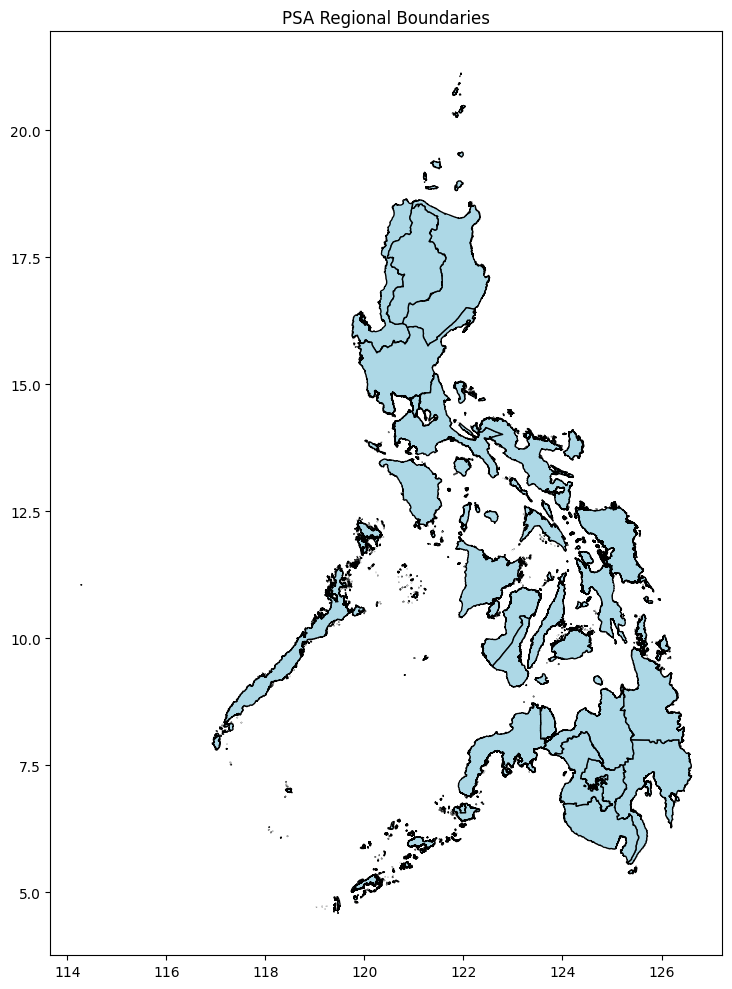

In [20]:
fig, ax = plt.subplots(figsize=(8, 10))
regions_gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue')
ax.set_title('PSA Regional Boundaries')
plt.tight_layout()
plt.show()

In [21]:
regions_gdf = regions_gdf[['ADM1_EN', 'geometry']].copy()
regions_gdf = regions_gdf.rename(columns={'ADM1_EN': 'region'})

print('Clean PSA shapefile:')
print(regions_gdf)

regions_gdf.to_file('../data_clean/regions_clean.gpkg', driver='GPKG')

Clean PSA shapefile:
                                               region  \
0                            Region I (Ilocos Region)   
1                          Region II (Cagayan Valley)   
2                          Region III (Central Luzon)   
3                            Region IV-A (Calabarzon)   
4                             Region V (Bicol Region)   
5                         Region VI (Western Visayas)   
6                        Region VII (Central Visayas)   
7                       Region VIII (Eastern Visayas)   
8                     Region IX (Zamboanga Peninsula)   
9                        Region X (Northern Mindanao)   
10                           Region XI (Davao Region)   
11                          Region XII (Soccsksargen)   
12                      National Capital Region (NCR)   
13             Cordillera Administrative Region (CAR)   
14                               Region XIII (Caraga)   
15                                    Mimaropa Region   
16  Bangsa